In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

In [3]:
conditions = [
    df["grades"] >= 80,  # good
    df["grades"] >= 60,  # sufficient
]
choices = ["good", "sufficient"]

df["grade_category"] = np.select(conditions, choices, default="fail")

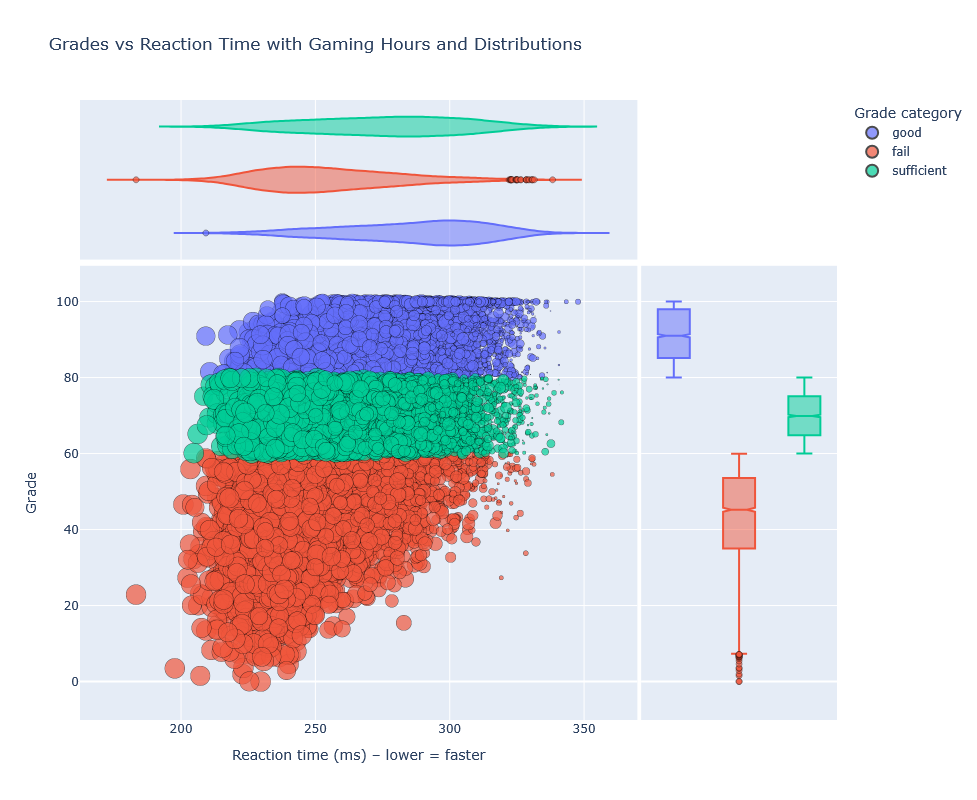

In [4]:
# Ensure we only use realistic grades
df_filtered = df[df["grades"] <= 100].copy()

fig = px.scatter(
    df_filtered,
    x="reaction_time_ms",
    y="grades",
    color="grade_category",       # color by grade category
    size="gaming_hours",          # larger bubbles = more gaming hours
    hover_data=[
        "student_id",
        "age",
        "gender",
        "gaming_hours",
        "study_hours",
        "reaction_time_ms",
        "grades",
        "grade_category",
    ],
    marginal_x="violin",          # distribution of reaction times
    marginal_y="box",             # distribution of grades
    title="Grades vs Reaction Time with Gaming Hours and Distributions",
    width=1000,
    height=800,
)

# Make points readable
fig.update_traces(marker=dict(opacity=0.7, line=dict(width=0.5, color="black")))

# Improve axis labels
fig.update_layout(
    xaxis_title="Reaction time (ms) – lower = faster",
    yaxis_title="Grade",
    legend_title_text="Grade category",
)

fig.show()